In [10]:
import os
import re
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import time
import gget
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import ttest_ind
from tqdm import tqdm
import textwrap

import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

from scvi.external import CellAssign

import cupy as cp
import cuml

sc.settings.verbosity = 3

# Load adata

In [9]:
%%time
fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/new_processed/fib_ihsc_processed.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 287 ms, sys: 1.35 s, total: 1.63 s
Wall time: 21.2 s


AnnData object with n_obs × n_vars = 15317 × 23434
    obs: 'batch', 'barcoded_phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'cluster'
    var: 'gene_id', 'gene_type', 'Chromosome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_rank', 'variances', 'variances_norm'
    uns: 'batch_colors', 'cluster_colors', 'dr

# Load Capybara scores

In [22]:
%%time
# Load Capybara output
# fpath_scale = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/capybara_basename_scale.csv"
# fpath_scale = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/basename_simple_scale.csv"
# fpath_scale = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/gomes_scale.csv"
fpath_scale = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/celltype_simplified_scale.csv"

df = pd.read_csv(fpath_scale)
print(f"{df.shape=}")
df.head()

df.shape=(15317, 18)
CPU times: user 36.3 ms, sys: 8.82 ms, total: 45.1 ms
Wall time: 85 ms


,cell_name,frxn_blood vessel endothelial cell,frxn_embryonic fibroblast,frxn_endothelial cell,frxn_endothelial cell of vascular tree,frxn_erythroid progenitor cell,frxn_fibro/adipogenic progenitor cell,frxn_fibroblast,frxn_hematopoietic multipotent progenitor cell,frxn_hematopoietic precursor cell,frxn_hematopoietic stem cell,frxn_megakaryocyte progenitor cell,frxn_retinal blood vessel endothelial cell,frxn_skeletal muscle fibroblast,frxn_skin fibroblast,frxn_vein endothelial cell,Lagrangian,Error
0,AAACCCAAGGTTACCT-1_hsc,0.032133,0.217016,0.089362,-1.502227e-18,0.142176,0.211293,-7.571988e-17,-2.317283e-17,6.267965e-02,3.516860e-02,-1.348299e-18,1.033704e-02,0.000000e+00,0.112415,-8.190032e-17,0,2332.512327
1,AAACCCAAGTTGAAGT-1_hsc,0.004663,0.167316,0.070082,-1.412583e-18,0.162263,0.306671,-8.641335e-17,-1.959392e-17,4.629240e-02,2.062320e-02,-6.473278e-19,8.433139e-02,0.000000e+00,0.043523,-4.114227e-17,0,2404.627863
2,AAACCCAAGTTGTCGT-1_hsc,0.042700,0.289247,0.006550,0.000000e+00,0.242192,0.140104,-1.140371e-17,1.273411e-17,2.055963e-02,3.061325e-17,8.214491e-18,2.372263e-18,-1.646951e-19,0.108224,1.825718e-17,0,2371.801089
3,AAACCCACAGAAGCGT-1_hsc,0.001366,0.242185,0.021702,-2.510081e-19,0.092797,0.192374,-1.993481e-18,-1.591642e-17,6.497617e-02,4.913225e-19,3.551646e-19,4.893641e-02,0.000000e+00,0.202499,1.916034e-17,0,2418.659557
4,AAACCCACAGGAGGTT-1_hsc,0.040214,0.223023,0.164420,9.392213e-19,0.178626,0.129039,-2.162870e-18,-5.825019e-17,-1.291351e-17,0.000000e+00,-4.825440e-18,3.703020e-02,-2.434538e-19,0.104846,3.773079e-17,0,2155.126194


In [23]:
# get source name 
match = re.search(r'/([^/]+)_scale\.csv$', fpath_scale)
if match:
    result = match.group(1)
    print(result)  # Output: basename_simple
else:
    print("No match found.")


# Set index to 'cell_name' for merging
df = df.set_index('cell_name')

# Sanity check: ensure all indices in df exist in adata.obs
common_cells = adata.obs.index.intersection(df.index)
print(f"Merging on {len(common_cells)} shared cells")

# Merge into adata.obs
adata.obs = adata.obs.join(df, how='left', rsuffix=f'_{result}')  # 'left' keeps all cells in adata.obs

adata.obs.head()

celltype_simplified
Merging on 15317 shared cells


,batch,barcoded_phase,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,...,frxn_hematopoietic multipotent progenitor cell,frxn_hematopoietic precursor cell,frxn_hematopoietic stem cell,frxn_megakaryocyte progenitor cell,frxn_retinal blood vessel endothelial cell,frxn_skeletal muscle fibroblast,frxn_skin fibroblast,frxn_vein endothelial cell,Lagrangian_celltype_simplified,Error_celltype_simplified
AAACCCAAGGTTACCT-1_hsc,hsc,unknown,3700,8.216358,11235.0,9.326878,27.850467,37.641300,47.396529,60.293725,...,-2.317283e-17,6.267965e-02,3.516860e-02,-1.348299e-18,1.033704e-02,0.000000e+00,0.112415,-8.190032e-17,0,2332.512327
AAACCCAAGTTGAAGT-1_hsc,hsc,unknown,4024,8.300280,10634.0,9.271906,24.637954,32.697010,40.671431,53.112658,...,-1.959392e-17,4.629240e-02,2.062320e-02,-6.473278e-19,8.433139e-02,0.000000e+00,0.043523,-4.114227e-17,0,2404.627863
AAACCCAAGTTGTCGT-1_hsc,hsc,unknown,2593,7.860956,6743.0,8.816408,28.503633,37.327599,48.079490,63.458401,...,1.273411e-17,2.055963e-02,3.061325e-17,8.214491e-18,2.372263e-18,-1.646951e-19,0.108224,1.825718e-17,0,2371.801089
AAACCCACAGAAGCGT-1_hsc,hsc,unknown,2371,7.771489,5430.0,8.599879,24.622468,34.696133,45.101289,60.515654,...,-1.591642e-17,6.497617e-02,4.913225e-19,3.551646e-19,4.893641e-02,0.000000e+00,0.202499,1.916034e-17,0,2418.659557
AAACCCACAGGAGGTT-1_hsc,hsc,unknown,5037,8.524764,22012.0,9.999388,31.737234,40.414319,50.000000,63.310921,...,-5.825019e-17,-1.291351e-17,0.000000e+00,-4.825440e-18,3.703020e-02,-2.434538e-19,0.104846,3.773079e-17,0,2155.126194


# Gomes

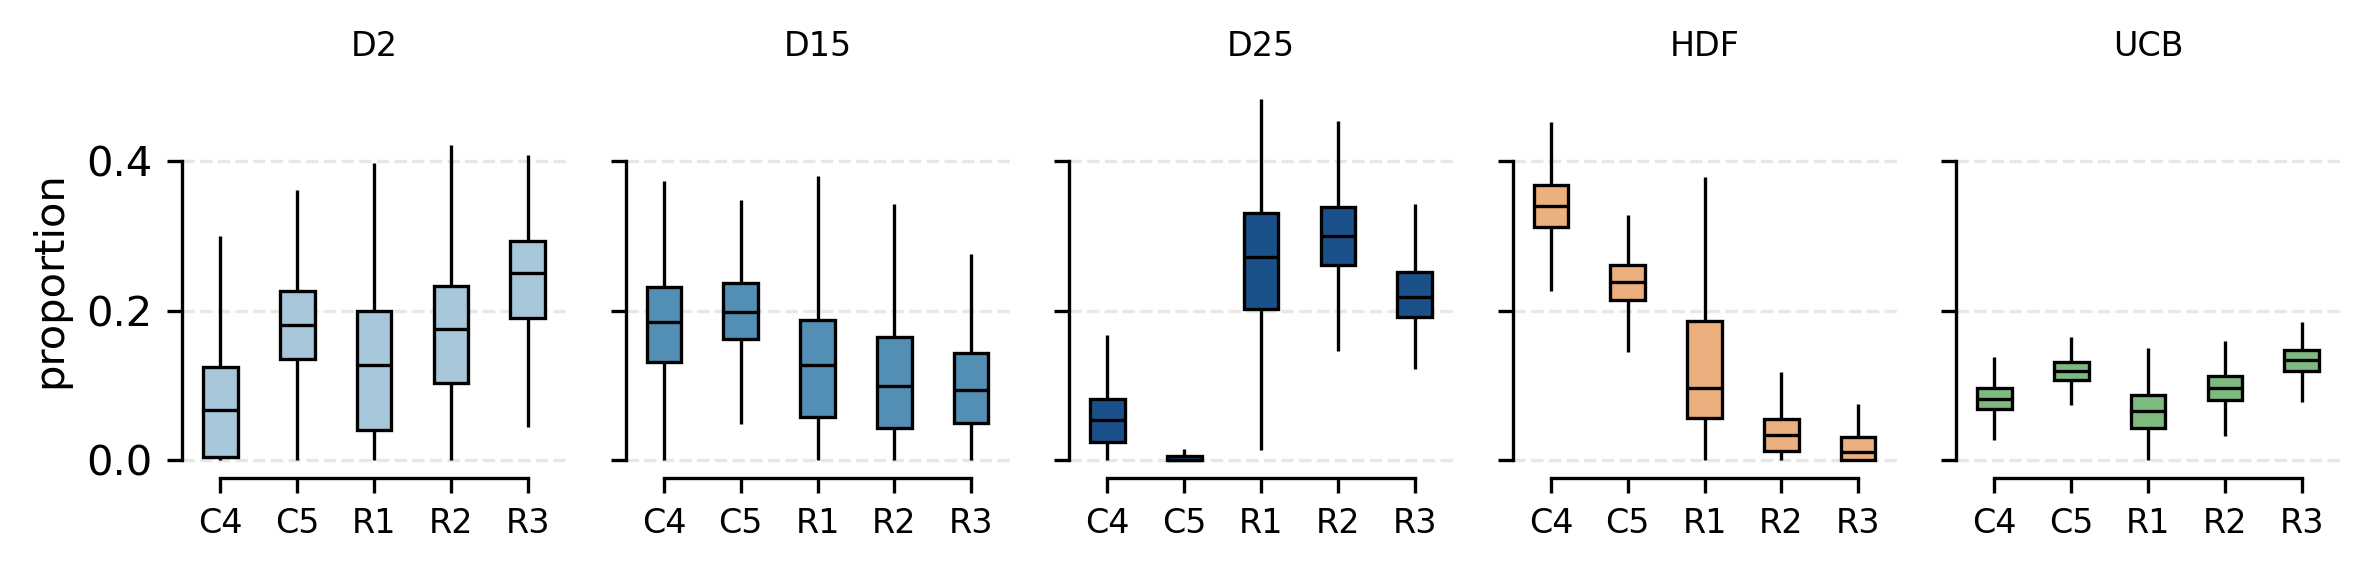

In [17]:
gomes_path = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/gomes_scale.csv"
gomes_df = pd.read_csv(gomes_path)

frxn_cols = [col for col in gomes_df.columns if col.startswith("frxn_")]

# Copy and melt
df = adata.obs.copy()
# frxn_cols = [col for col in df.columns if col.startswith("frxn_")]
df_melted = df.melt(
    id_vars=["cluster"],
    value_vars=frxn_cols,
    var_name="Cell Type",
    value_name="Fraction"
)

df_melted['Cell Type'] = df_melted['Cell Type'].str.replace('frxn_', '').str.replace('DAY', 'D')
df_melted = df_melted.sort_values('Cell Type', ascending=False)

palette = {
    'D2': '#9ecae1',   # light blue
    'D15': '#4292c6',  # medium blue
    'D25': '#08519c',  # dark blue
    'HDF': '#fdae6b',  # orange
    'UCB': '#74c476'   # green
}


# Plot with FacetGrid
g = sns.FacetGrid(
    df_melted,
    col="Cell Type",
    col_wrap=5,
    sharey=True,
    height=2,
    aspect=0.8,
    col_order=['D2', 'D15', 'D25', 'HDF', 'UCB'],
)

g.map_dataframe(
    sns.boxplot,
    x="cluster",
    y="Fraction",
    hue='Cell Type',
    order=sorted(df["cluster"].unique()),
    width=0.45,
    linecolor='k',
    palette=palette,
    capprops={'linewidth': 0},  
    showfliers=False,
    linewidth=0.8
)

g.set_axis_labels("", "proportion")
g.set_titles(col_template="{col_name}", size=8)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

g.fig.subplots_adjust(wspace=0.2)

plt.tight_layout()
sns.despine(trim=True)
plt.show()

[<Axes: title={'center': 'D15 (CD49f+)'}, xlabel='FA1', ylabel='FA2'>,
 <Axes: title={'center': 'D25 (CD34+CD49f+)'}, xlabel='FA1', ylabel='FA2'>,
 <Axes: title={'center': 'HDF'}, xlabel='FA1', ylabel='FA2'>]

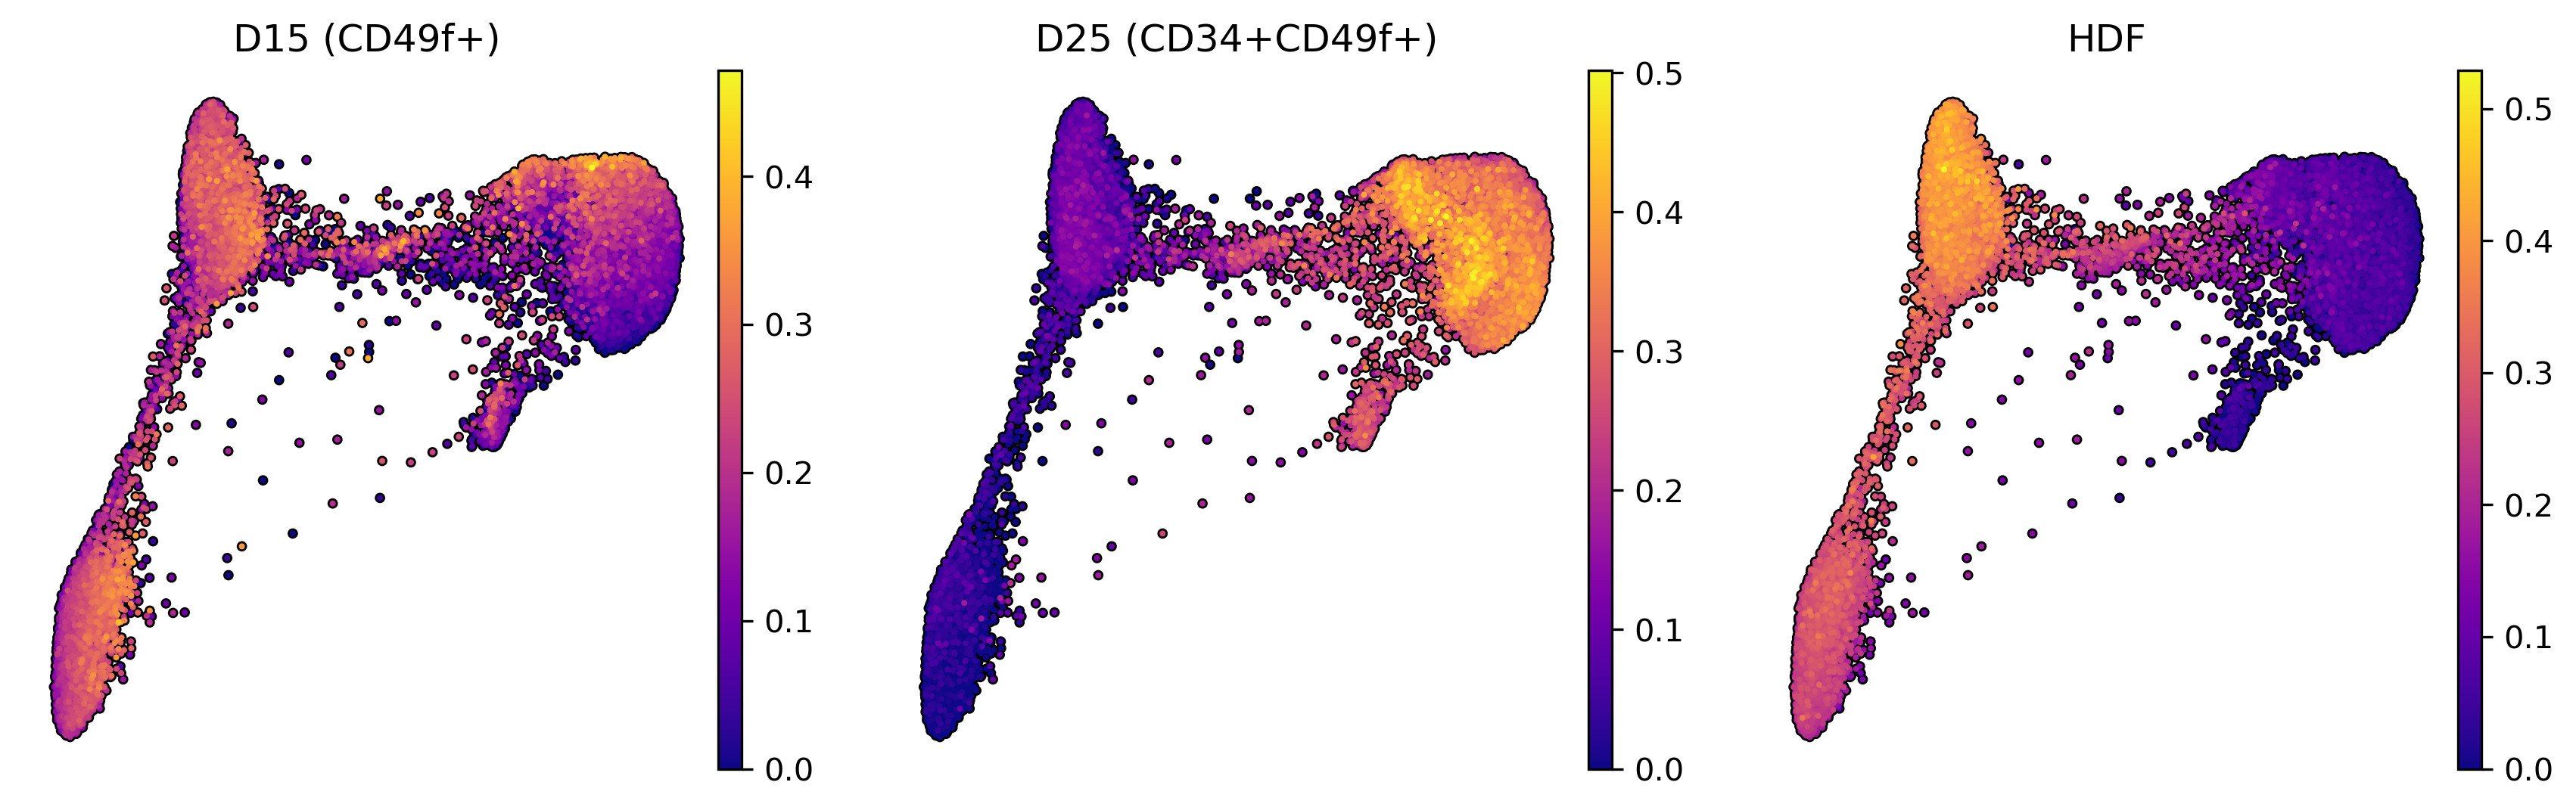

In [18]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata, 
    color=['frxn_DAY15', 'frxn_DAY25', 'frxn_HDF'],
    size=15,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    na_in_legend=False,
    cmap='plasma',
    title=['D15 (CD49f+)', 'D25 (CD34+CD49f+)', 'HDF'],
    frameon=False,
    wspace=0.15,
    show=False, 
)

# Basename simple

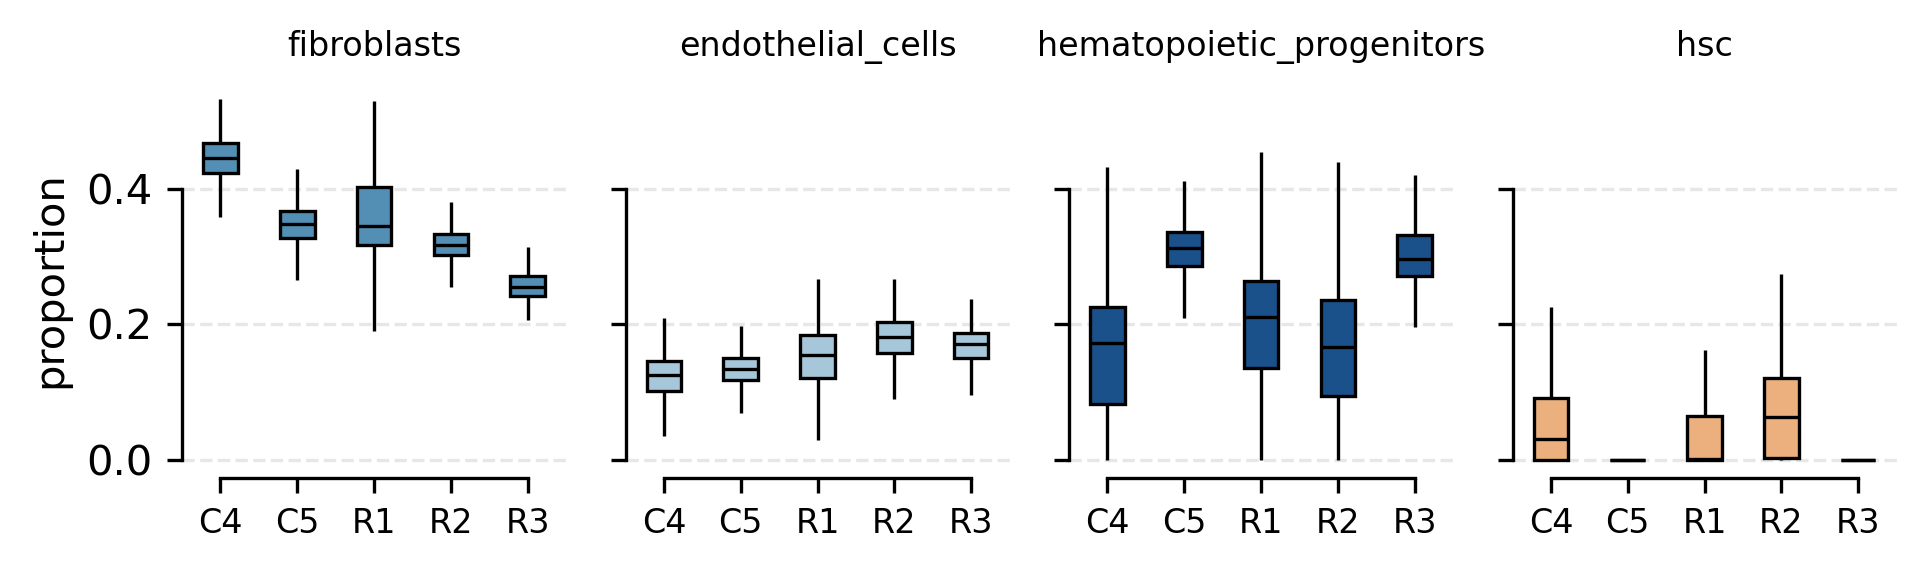

In [20]:
basename_path = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/basename_simple_scale.csv"
basename_df = pd.read_csv(basename_path)

frxn_cols = [col for col in basename_df.columns if col.startswith("frxn_")]


# Copy and melt
df = adata.obs.copy()
# frxn_cols = [col for col in df.columns if col.startswith("frxn_")]
df_melted = df.melt(
    id_vars=["cluster"],
    value_vars=frxn_cols,
    var_name="Cell Type",
    value_name="Fraction"
)

df_melted['Cell Type'] = df_melted['Cell Type'].str.replace('frxn_', '')#.str.replace('_', ' ')
df_melted = df_melted.sort_values('Cell Type', ascending=False)

palette = {
    'endothelial_cells': '#9ecae1',   # light blue
    'fibroblasts': '#4292c6',  # medium blue
    'hematopoietic_progenitors': '#08519c',  # dark blue
    'hsc': '#fdae6b',  # orange
}


# Plot with FacetGrid
g = sns.FacetGrid(
    df_melted,
    col="Cell Type",
    col_wrap=5,
    sharey=True,
    height=2,
    aspect=0.8,
    col_order=['fibroblasts', 'endothelial_cells', 'hematopoietic_progenitors', 'hsc'],
)

g.map_dataframe(
    sns.boxplot,
    x="cluster",
    y="Fraction",
    hue='Cell Type',
    order=sorted(df["cluster"].unique()),
    width=0.45,
    linecolor='k',
    palette=palette,
    capprops={'linewidth': 0},  
    showfliers=False,
    linewidth=0.8
)

g.set_axis_labels("", "proportion")
g.set_titles(col_template="{col_name}", size=8)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

g.fig.subplots_adjust(wspace=0.2)

plt.tight_layout()
sns.despine(trim=True)
plt.show()

[<Axes: title={'center': 'endo'}, xlabel='FA1', ylabel='FA2'>,
 <Axes: title={'center': 'fib'}, xlabel='FA1', ylabel='FA2'>,
 <Axes: title={'center': 'progenitors'}, xlabel='FA1', ylabel='FA2'>,
 <Axes: title={'center': 'hsc'}, xlabel='FA1', ylabel='FA2'>]

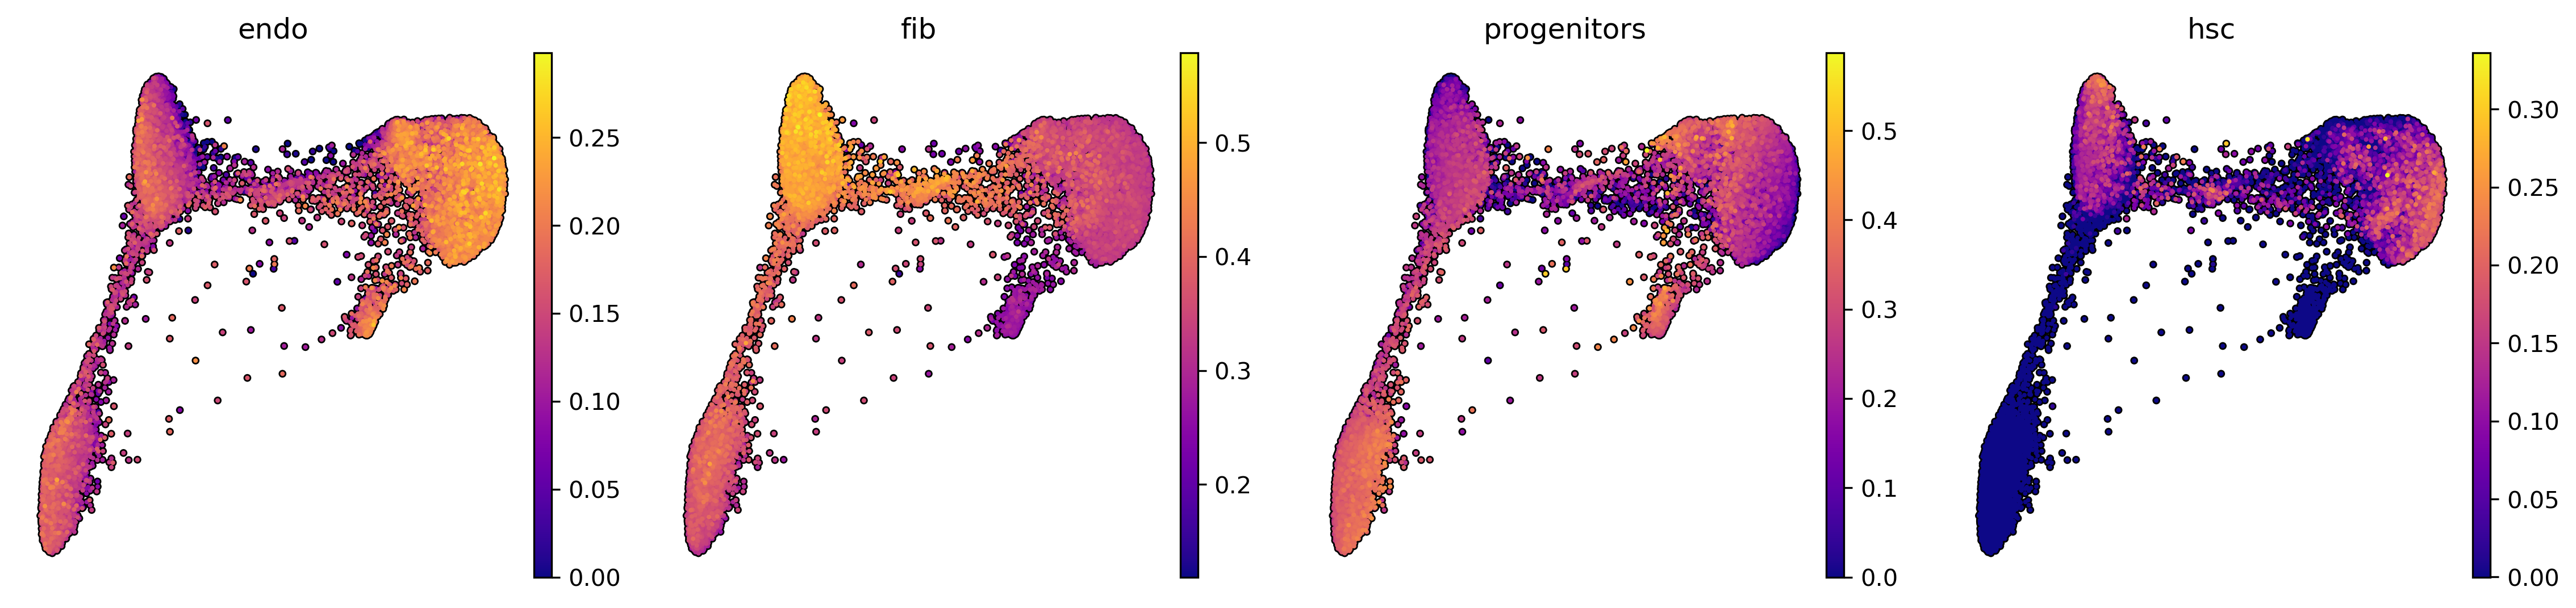

In [21]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata, 
    color=['frxn_endothelial_cells', 'frxn_fibroblasts', 'frxn_hematopoietic_progenitors', 'frxn_hsc'],
    size=15,
    ncols=4,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    na_in_legend=False,
    cmap='plasma',
    title=['endo', 'fib', 'progenitors', 'hsc'],
    frameon=False,
    wspace=0.15,
    show=False, 
)

# Cell type (basename)

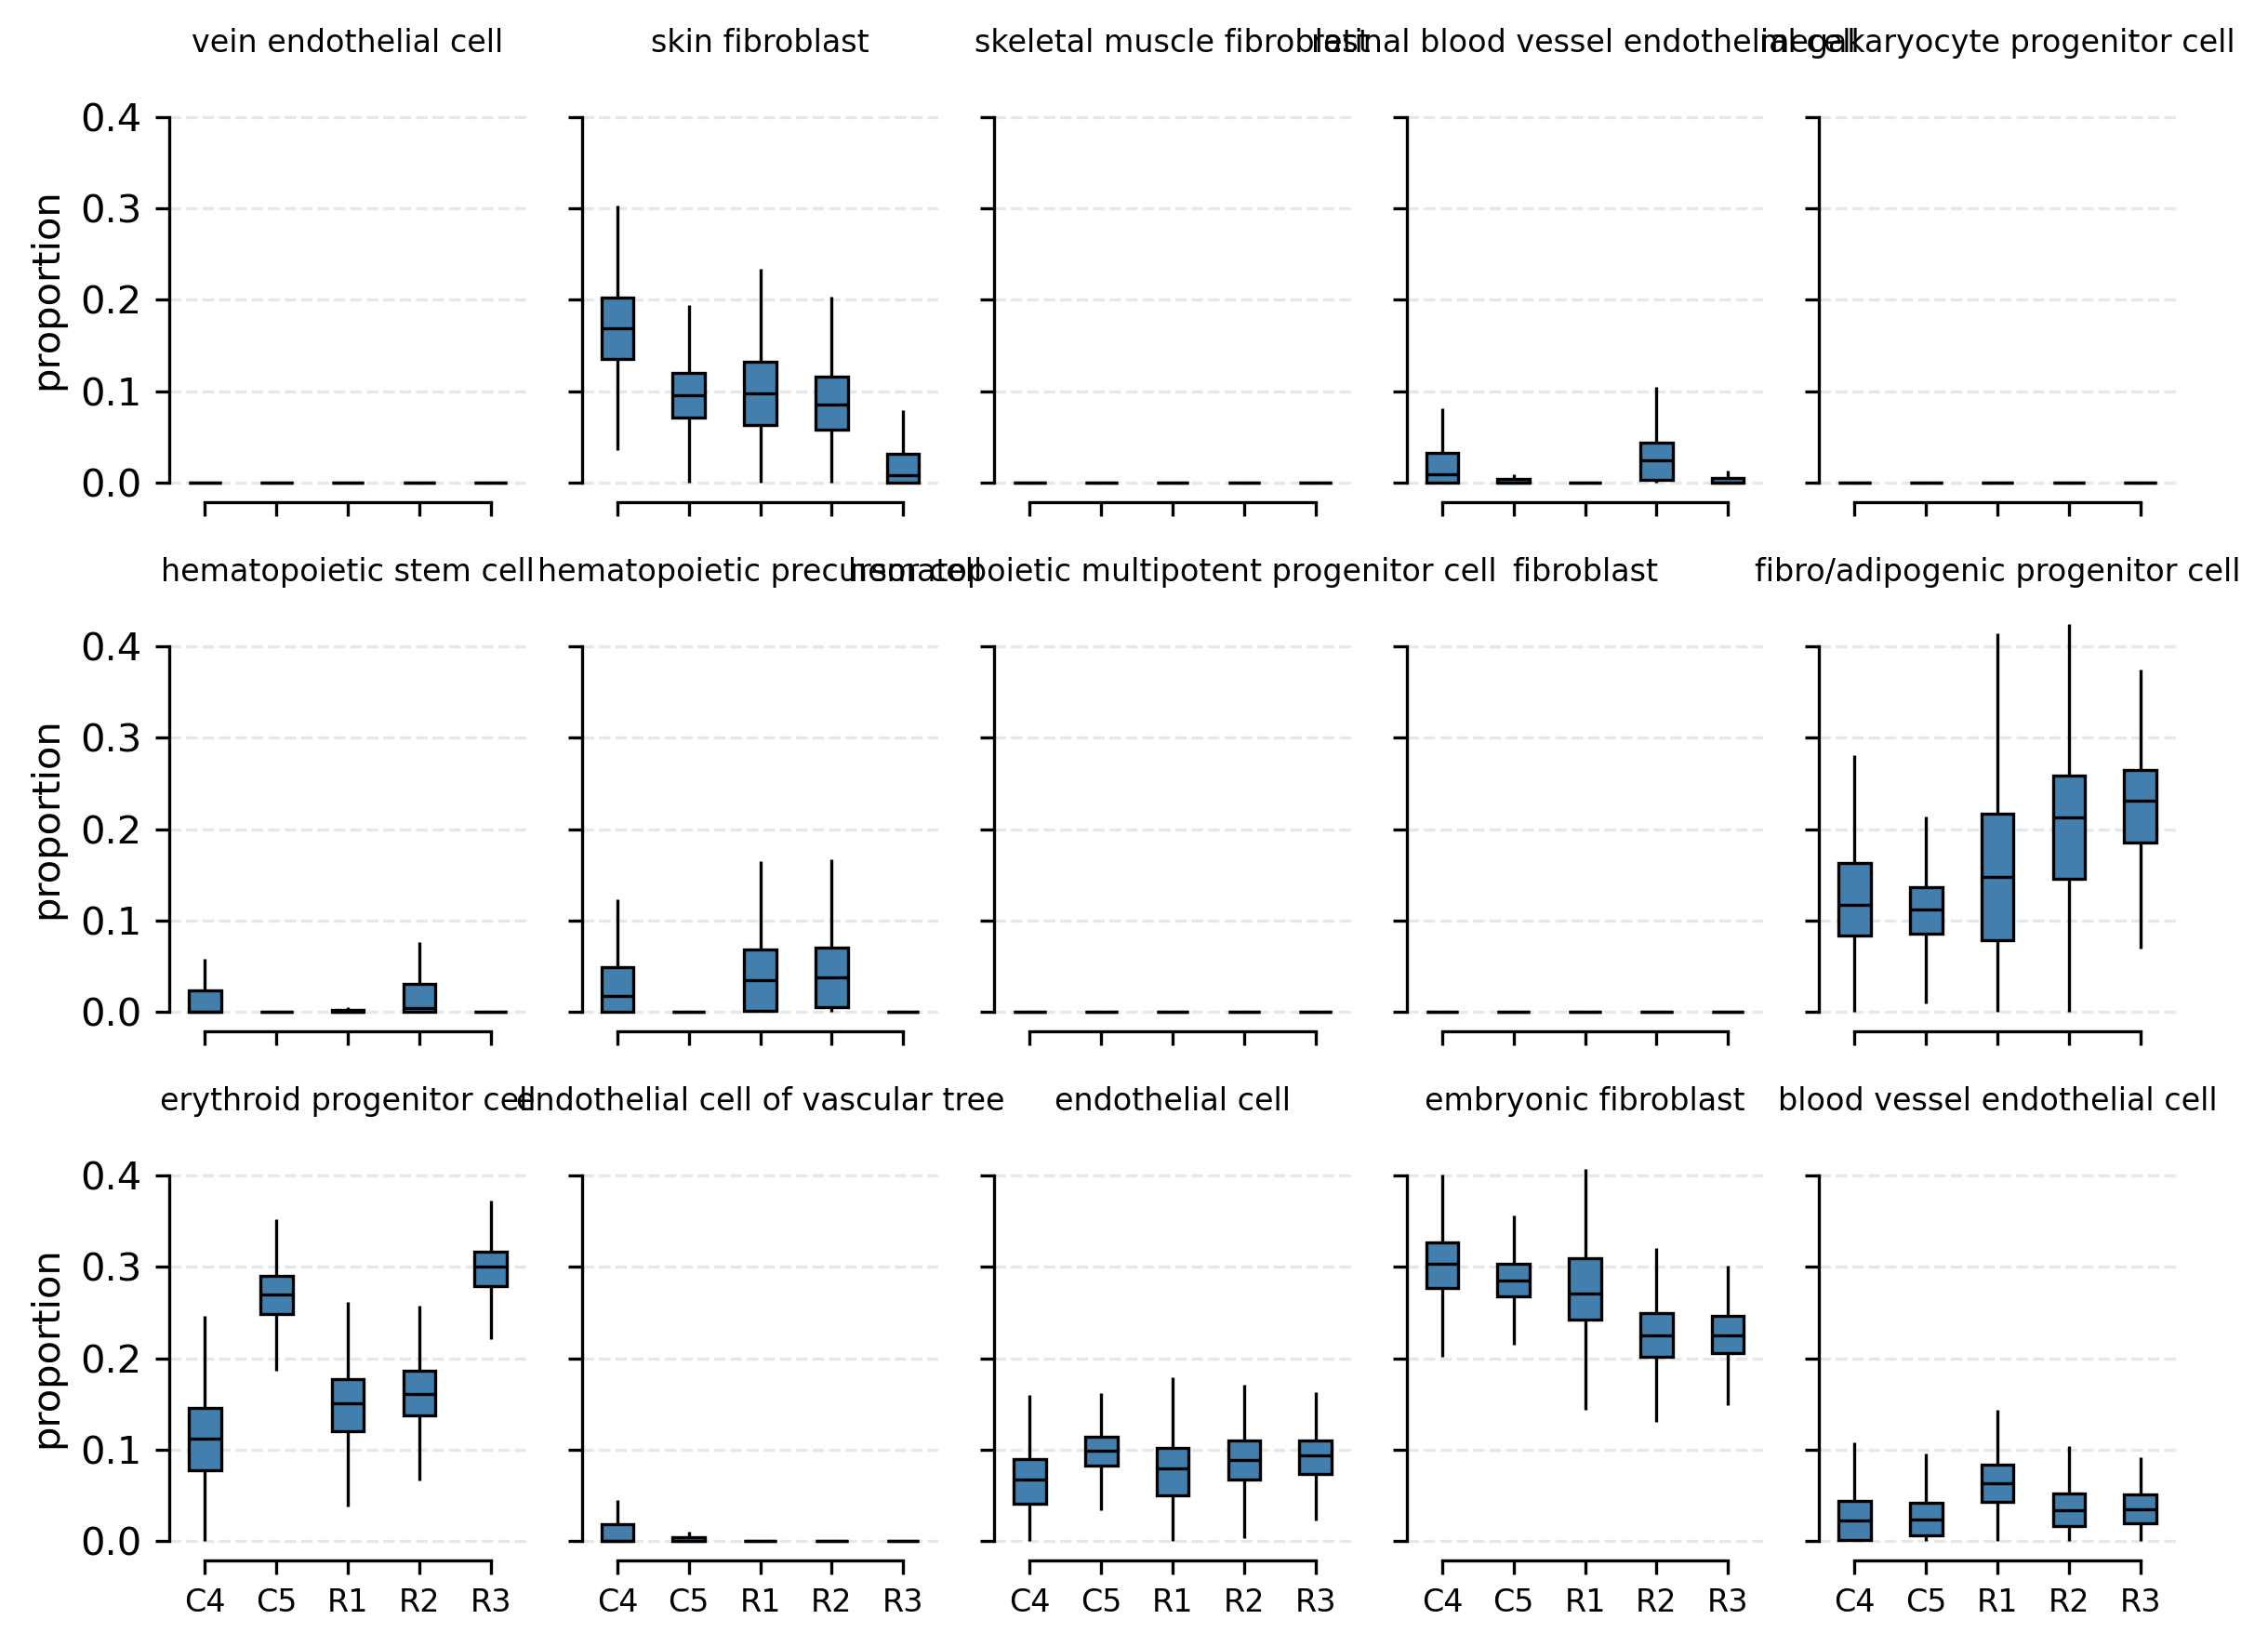

In [25]:
basename_path = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/celltype_simplified_scale.csv"
basename_df = pd.read_csv(basename_path)

frxn_cols = [col for col in basename_df.columns if col.startswith("frxn_")]


# Copy and melt
df = adata.obs.copy()
# frxn_cols = [col for col in df.columns if col.startswith("frxn_")]
df_melted = df.melt(
    id_vars=["cluster"],
    value_vars=frxn_cols,
    var_name="Cell Type",
    value_name="Fraction"
)

df_melted['Cell Type'] = df_melted['Cell Type'].str.replace('frxn_', '')#.str.replace('_', ' ')
df_melted = df_melted.sort_values('Cell Type', ascending=False)

# palette = {
#     'endothelial_cells': '#9ecae1',   # light blue
#     'fibroblasts': '#4292c6',  # medium blue
#     'hematopoietic_progenitors': '#08519c',  # dark blue
#     'hsc': '#fdae6b',  # orange
# }


# Plot with FacetGrid
g = sns.FacetGrid(
    df_melted,
    col="Cell Type",
    col_wrap=5,
    sharey=True,
    height=2,
    aspect=0.8,
    # col_order=['fibroblasts', 'endothelial_cells', 'hematopoietic_progenitors', 'hsc'],
)

g.map_dataframe(
    sns.boxplot,
    x="cluster",
    y="Fraction",
    hue='Cell Type',
    order=sorted(df["cluster"].unique()),
    width=0.45,
    linecolor='k',
    palette='tab20c',
    capprops={'linewidth': 0},  
    showfliers=False,
    linewidth=0.8
)

g.set_axis_labels("", "proportion")
g.set_titles(col_template="{col_name}", size=8)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

g.fig.subplots_adjust(wspace=0.2)

plt.tight_layout()
sns.despine(trim=True)
plt.show()

In [26]:
frxn_cols

['frxn_blood vessel endothelial cell',
 'frxn_embryonic fibroblast',
 'frxn_endothelial cell',
 'frxn_endothelial cell of vascular tree',
 'frxn_erythroid progenitor cell',
 'frxn_fibro/adipogenic progenitor cell',
 'frxn_fibroblast',
 'frxn_hematopoietic multipotent progenitor cell',
 'frxn_hematopoietic precursor cell',
 'frxn_hematopoietic stem cell',
 'frxn_megakaryocyte progenitor cell',
 'frxn_retinal blood vessel endothelial cell',
 'frxn_skeletal muscle fibroblast',
 'frxn_skin fibroblast',
 'frxn_vein endothelial cell']

[<Axes: title={'center': 'skin fib'}, xlabel='FA1', ylabel='FA2'>,
 <Axes: title={'center': 'hsc'}, xlabel='FA1', ylabel='FA2'>,
 <Axes: title={'center': 'hema precursor'}, xlabel='FA1', ylabel='FA2'>,
 <Axes: title={'center': 'embry fib'}, xlabel='FA1', ylabel='FA2'>]

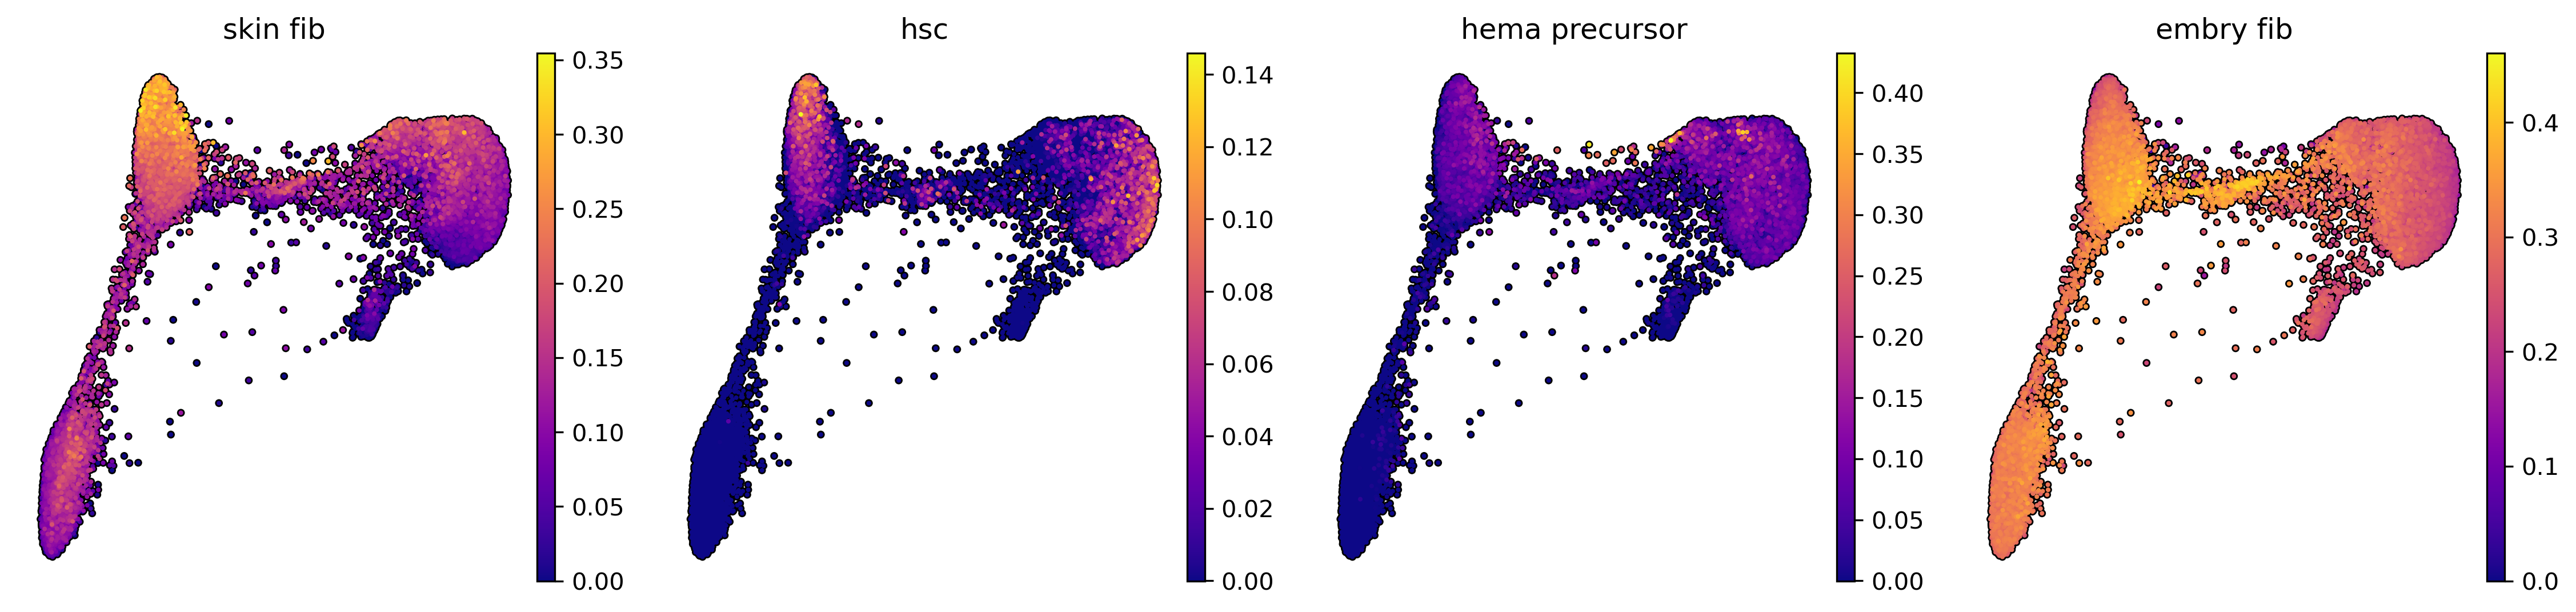

In [27]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata, 
    color=['frxn_skin fibroblast', 'frxn_hematopoietic stem cell', 'frxn_hematopoietic precursor cell', 'frxn_embryonic fibroblast'],
    size=15,
    ncols=4,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    na_in_legend=False,
    cmap='plasma',
    title=['skin fib', 'hsc', 'hema precursor', 'embry fib'],
    frameon=False,
    wspace=0.15,
    show=False, 
)

In [30]:
frxn_cols = [
    'frxn_skin fibroblast',
    'frxn_hematopoietic stem cell',
    'frxn_embryonic fibroblast',
    'frxn_hematopoietic precursor cell',
    'frxn_fibroblasts',
    'frxn_hsc',
    'frxn_endothelial_cells',
    'frxn_DAY25', 
    'frxn_HDF',
]
    

# Copy and melt
df = adata.obs.copy()
# frxn_cols = [col for col in df.columns if col.startswith("frxn_")]
df_melted = df.melt(
    id_vars=["cluster"],
    value_vars=frxn_cols,
    var_name="Cell Type",
    value_name="Fraction"
)

# group control clusters


df_melted.head()

,cluster,Cell Type,Fraction
0,R2,frxn_skin fibroblast,0.112415
1,R2,frxn_skin fibroblast,0.043523
2,C5,frxn_skin fibroblast,0.108224
3,C4,frxn_skin fibroblast,0.202499
4,R2,frxn_skin fibroblast,0.104846


In [ ]:
cluster_count = adata.obs['cluster'].value_counts()



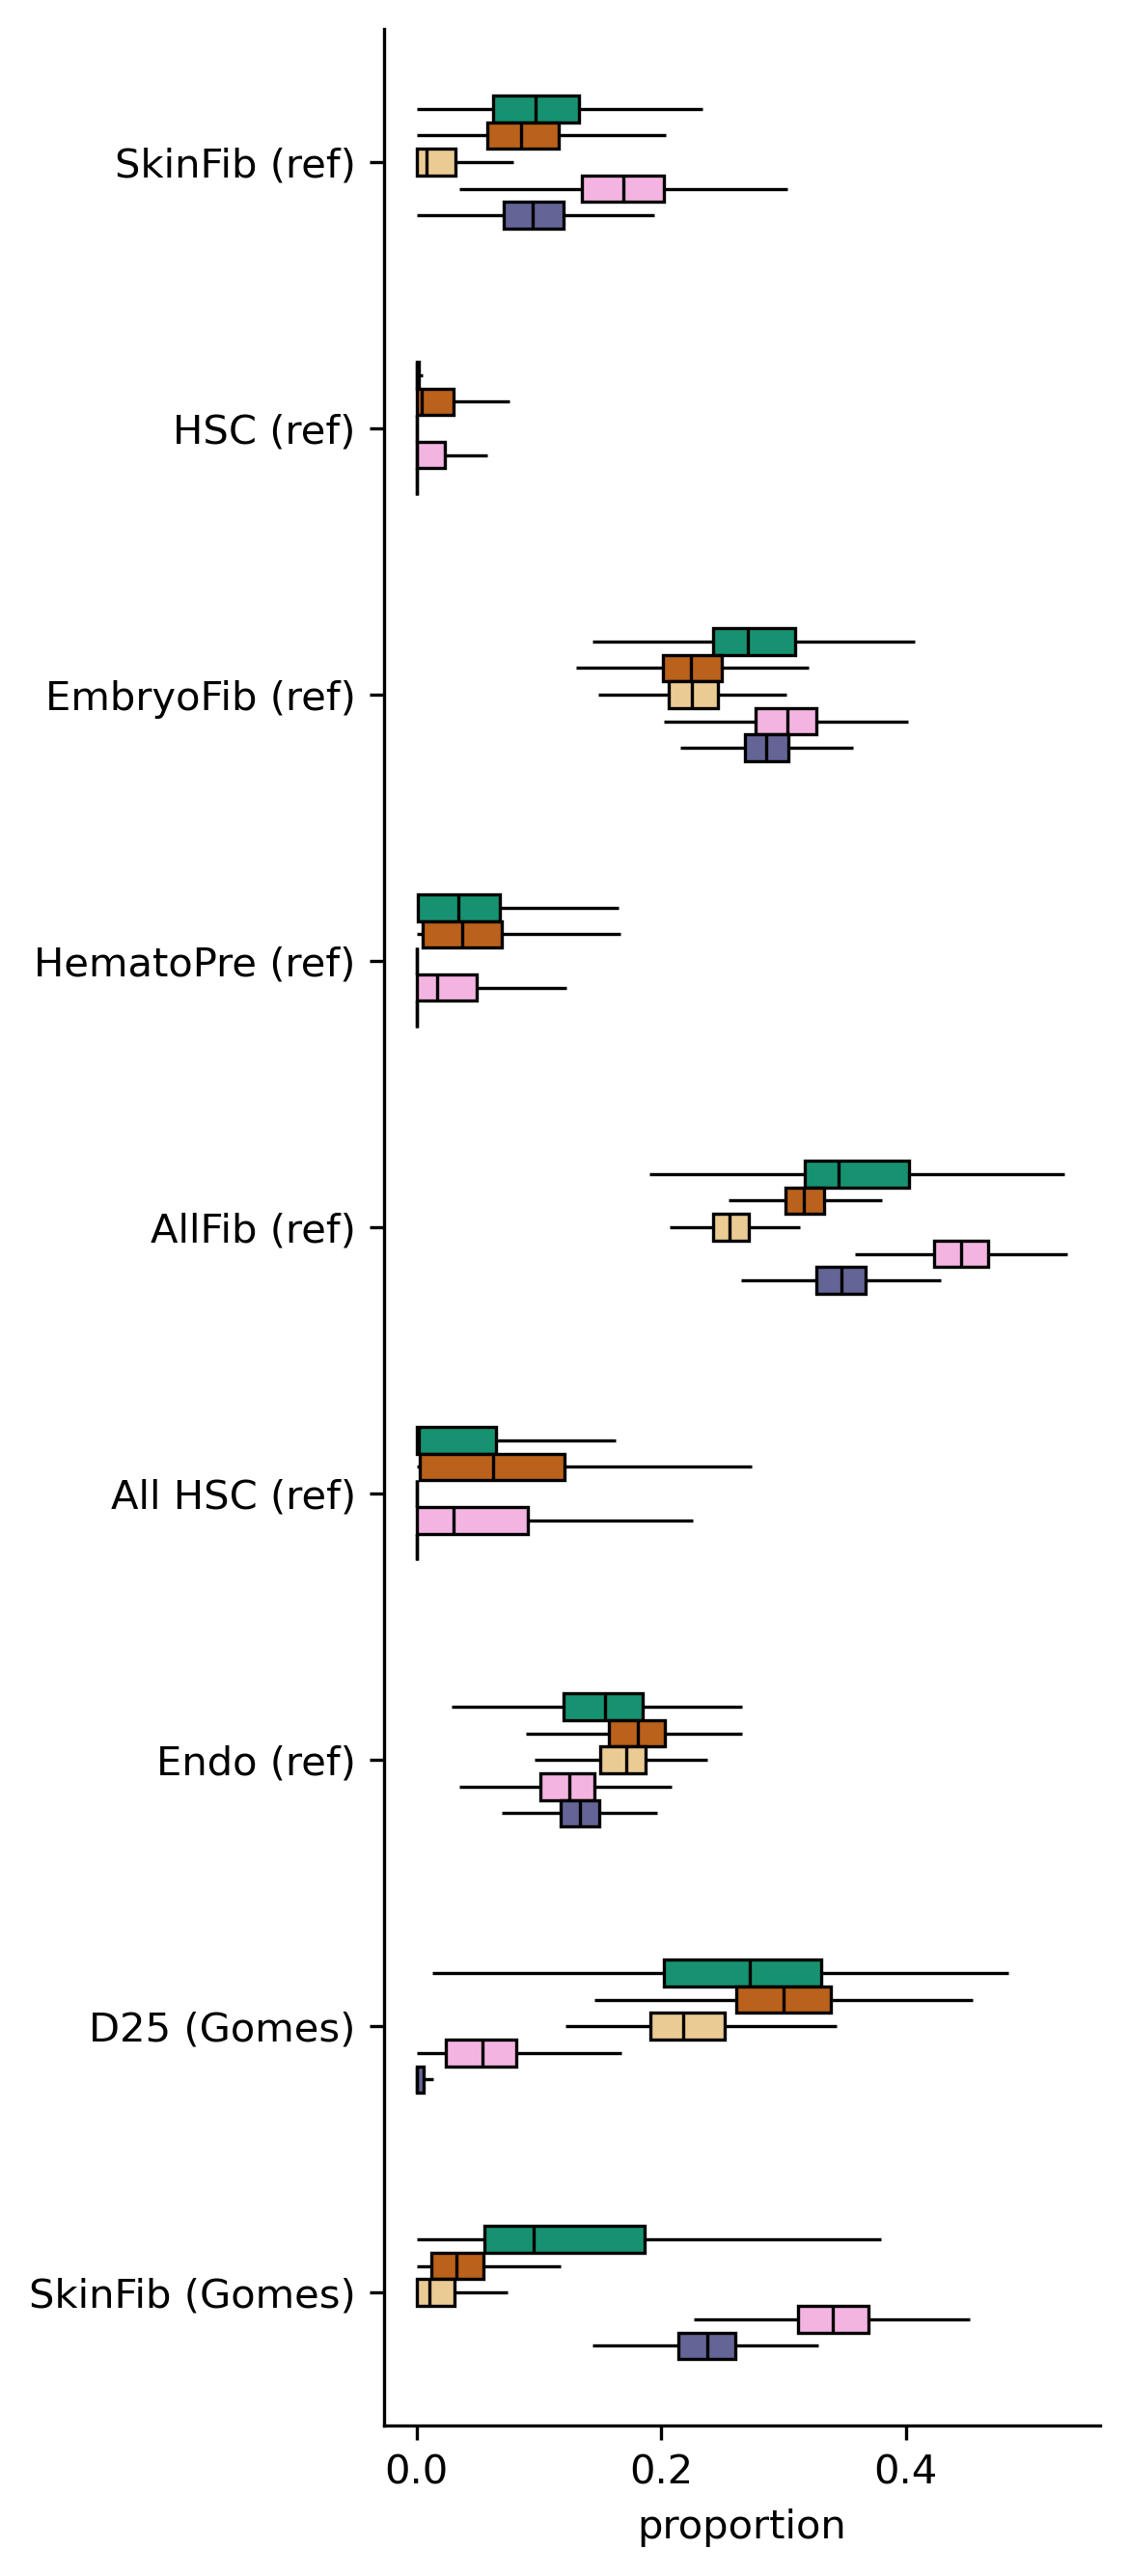

In [39]:
plt.rcParams['figure.dpi']    = 300
plt.rcParams['figure.figsize'] = 4, len(frxn_cols)

label_map = {
    'frxn_skin fibroblast': 'SkinFib (ref)',
    'frxn_hematopoietic stem cell': 'HSC (ref)',
    'frxn_embryonic fibroblast': 'EmbryoFib (ref)',
    'frxn_hematopoietic precursor cell': 'HematoPre (ref)',
    'frxn_fibroblasts': 'AllFib (ref)',
    'frxn_hsc': 'All HSC (ref)',
    'frxn_endothelial_cells': 'Endo (ref)',
    'frxn_DAY25': 'D25 (Gomes)',
    'frxn_HDF': 'SkinFib (Gomes)',
}


cluster_colors = {
    'R1': '#02A679',
    'R2': '#D55E00',
    'R3': '#F9CF86',
    'C4': '#FFA9E6',
    'C5': '#5C5D9E',
}

sns.boxplot(
    df_melted,
    y='Cell Type',
    x='Fraction',
    hue='cluster',
    hue_order=['R1', 'R2', 'R3', 'C4', 'C5'],
    palette=cluster_colors,
    showfliers=False,
    linecolor='k',
    linewidth=0.8,
    width=0.5,
    capprops={'linewidth': 0},   
    legend=False,
)


plt.ylabel("")
plt.xlabel("proportion")

ax = plt.gca()
ax.set_yticks(range(len(frxn_cols)))
ax.set_yticklabels([label_map.get(g, g) for g in frxn_cols], fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()